# Previsão de Volume de Atendimentos — 2026
### Modelos: ARIMA · Prophet · Random Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

df_raw = pd.read_csv('../Bases/VolumeDeAtendimentos.csv', sep=';', parse_dates=['data'])
df_raw.head()

,Unnamed: 0,data,empresa,produto,volume_atendimentos
0,0,2021-01-01,EMP1,Parabrisa,37
1,1,2021-01-01,EMP1,Vigia,37
2,2,2021-01-01,EMP1,Laterais,22
3,3,2021-01-01,EMP1,Retrovisor,14
4,4,2021-01-01,EMP1,Farol,24


Período: 2021-01-01 → 2025-12-31
Total de dias: 1826
Valores nulos: 0


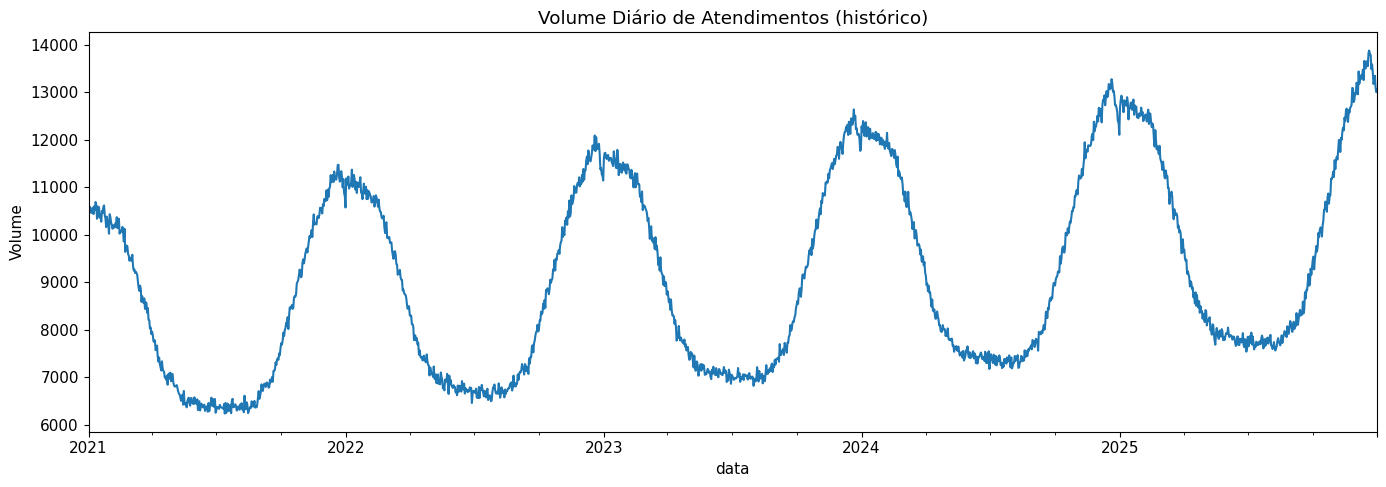

In [2]:
# Agrega volume total diário (todas as empresas e produtos)
serie = (
    df_raw
    .groupby('data')['volume_atendimentos']
    .sum()
    .asfreq('D')
    .rename('volume')
)
print(f"Período: {serie.index.min().date()} → {serie.index.max().date()}")
print(f"Total de dias: {len(serie)}")
print(f"Valores nulos: {serie.isna().sum()}")
serie.plot(title='Volume Diário de Atendimentos (histórico)', ylabel='Volume');
plt.tight_layout()
plt.show()

## 1. ARIMA

In [3]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

# Teste de estacionariedade
result = adfuller(serie.dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print("Série estacionária:", result[1] < 0.05)

ADF Statistic: -5.9487
p-value: 0.0000
Série estacionária: True


In [4]:
from pmdarima import auto_arima

# auto_arima busca os melhores parâmetros (p,d,q)(P,D,Q,s=7)
print("Buscando melhores parâmetros SARIMA (pode levar alguns minutos)...")
arima_model = auto_arima(
    serie,
    seasonal=True,
    m=7,                  # sazonalidade semanal
    stepwise=True,
    information_criterion='aic',
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    d=None, D=None
)
print("\nMelhor modelo:", arima_model.order, arima_model.seasonal_order)

Buscando melhores parâmetros SARIMA (pode levar alguns minutos)...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=22669.694, Time=2.57 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=23256.061, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=22998.675, Time=0.42 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=22992.282, Time=0.49 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=23254.250, Time=0.01 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=22663.067, Time=2.48 sec
 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=22662.513, Time=1.19 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=22663.001, Time=2.31 sec
 ARIMA(1,1,2)(0,0,0)[7] intercept   : AIC=22662.448, Time=0.90 sec
 ARIMA(1,1,2)(1,0,0)[7] intercept   : AIC=22663.178, Time=1.75 sec
 ARIMA(1,1,2)(0,0,1)[7] intercept   : AIC=22663.241, Time=2.30 sec
 ARIMA(1,1,2)(1,0,1)[7] intercept   : AIC=22671.900, Time=1.68 sec
 ARIMA(0,1,2)(0,0,0)[7] intercept   : AIC=22993.622, Time=0.27 sec
 ARIMA(1,1,1)(0,0,0

In [5]:
# Previsão para todos os dias de 2026
future_index_arima = pd.date_range('2026-01-01', '2026-12-31', freq='D')
n_periods = len(future_index_arima)

forecast_arima, conf_int_arima = arima_model.predict(
    n_periods=n_periods,
    return_conf_int=True,
    alpha=0.05
)

df_arima = pd.DataFrame({
    'data': future_index_arima,
    'previsao_arima': forecast_arima,
    'lower_arima': conf_int_arima[:, 0],
    'upper_arima': conf_int_arima[:, 1]
}).set_index('data')

df_arima.head(10)

,previsao_arima,lower_arima,upper_arima
data,,,
2026-01-01,13051.042769,12816.337962,13285.747577
2026-01-02,13013.936346,12757.853500,13270.019191
2026-01-03,12975.938205,12699.704025,13252.172385
2026-01-04,12938.329599,12640.042722,13236.616476
2026-01-05,12901.106534,12579.039989,13223.173079
2026-01-06,12864.265058,12516.852823,13211.677292
2026-01-07,12827.801259,12453.621821,13201.980696
2026-01-08,12791.711265,12389.470827,13193.951702
2026-01-09,12755.991244,12324.507972,13187.474517


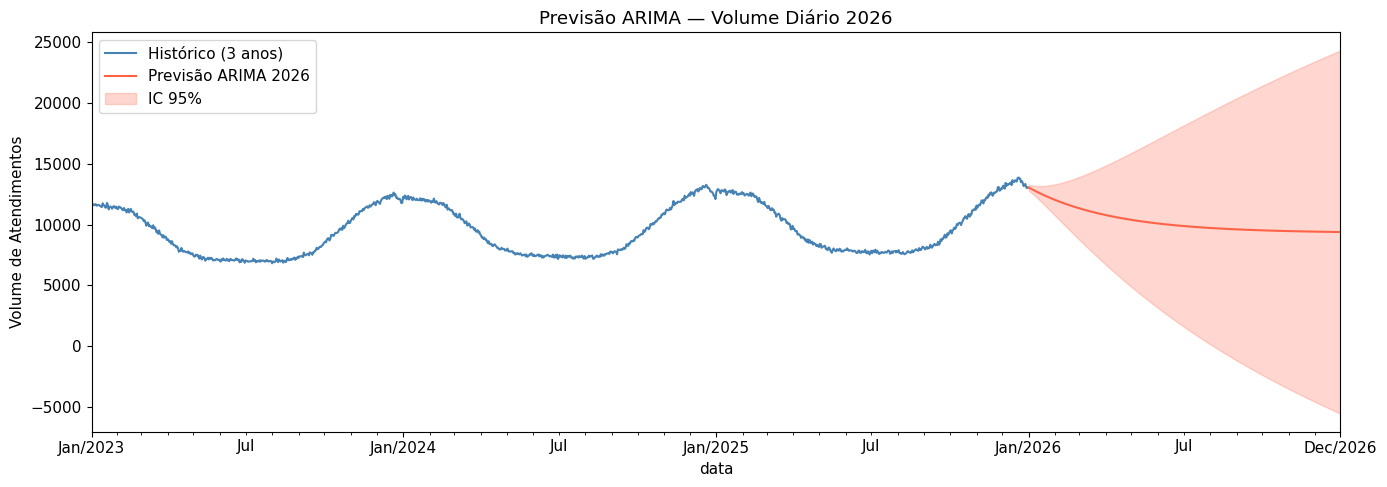


Total previsto 2026 (ARIMA): 3,753,987


In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
serie.iloc[-1095:].plot(ax=ax, label='Histórico (3 anos)', color='steelblue')
df_arima['previsao_arima'].plot(ax=ax, label='Previsão ARIMA 2026', color='tomato')
ax.fill_between(df_arima.index,
                df_arima['lower_arima'],
                df_arima['upper_arima'],
                alpha=0.25, color='tomato', label='IC 95%')
ax.set_title('Previsão ARIMA — Volume Diário 2026')
ax.set_ylabel('Volume de Atendimentos')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
plt.tight_layout()
plt.show()

print(f"\nTotal previsto 2026 (ARIMA): {df_arima['previsao_arima'].sum():,.0f}")

## 2. Prophet

In [7]:
from prophet import Prophet

# Prophet exige colunas 'ds' e 'y'
df_prophet_train = serie.reset_index().rename(columns={'data': 'ds', 'volume': 'y'})

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    interval_width=0.95,
    changepoint_prior_scale=0.1
)

# Feriados brasileiros relevantes
from prophet.make_holidays import make_holidays_df
br_holidays = make_holidays_df(year_list=[2021, 2022, 2023, 2024, 2025, 2026], country='BR')
model_prophet.add_country_holidays(country_name='BR')

model_prophet.fit(df_prophet_train)
print("Prophet treinado com sucesso.")

15:59:48 - cmdstanpy - INFO - Chain [1] start processing
15:59:49 - cmdstanpy - INFO - Chain [1] done processing


Prophet treinado com sucesso.


In [8]:
future_prophet = model_prophet.make_future_dataframe(periods=365, freq='D')
forecast_prophet = model_prophet.predict(future_prophet)

df_prophet = (
    forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    .rename(columns={'ds': 'data', 'yhat': 'previsao_prophet',
                     'yhat_lower': 'lower_prophet', 'yhat_upper': 'upper_prophet'})
    .set_index('data')
)
df_prophet_2026 = df_prophet['2026-01-01':'2026-12-31']
df_prophet_2026.head(10)

,previsao_prophet,lower_prophet,upper_prophet
data,,,
2026-01-01,13394.500534,13189.372235,13610.766008
2026-01-02,13379.464478,13180.113395,13589.572864
2026-01-03,13362.535557,13137.531405,13583.641142
2026-01-04,13354.208061,13137.230998,13566.394882
2026-01-05,13339.571538,13105.032378,13554.115775
2026-01-06,13317.071788,13090.141717,13521.700789
2026-01-07,13321.336724,13105.120379,13531.036668
2026-01-08,13316.240888,13108.122896,13524.129407
2026-01-09,13305.733265,13080.207142,13519.595195


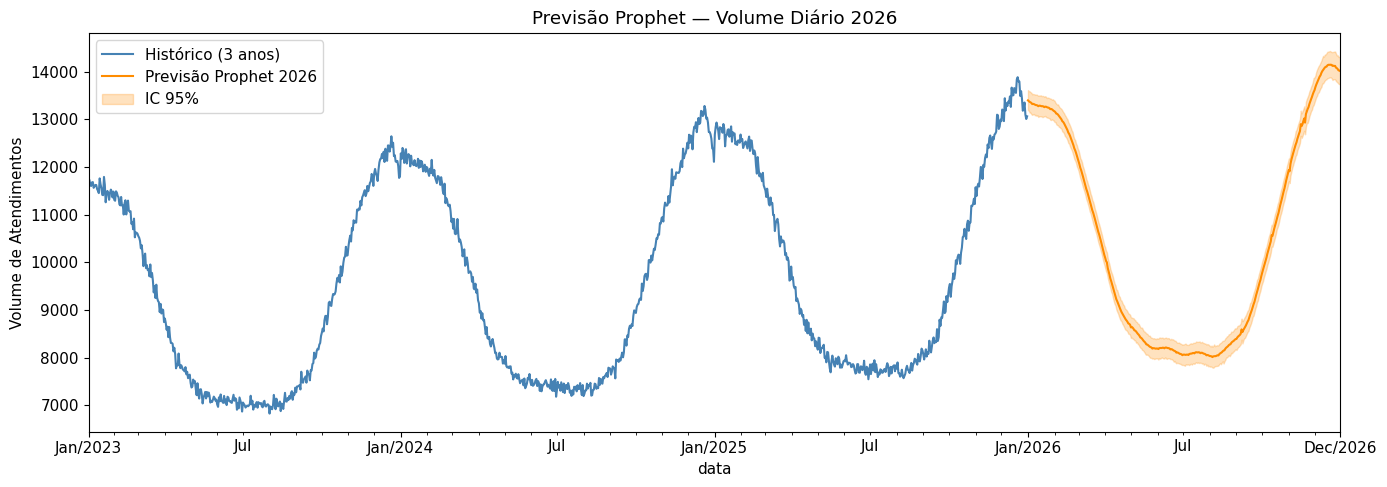


Total previsto 2026 (Prophet): 3,819,954


In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
serie.iloc[-1095:].plot(ax=ax, label='Histórico (3 anos)', color='steelblue')
df_prophet_2026['previsao_prophet'].plot(ax=ax, label='Previsão Prophet 2026', color='darkorange')
ax.fill_between(df_prophet_2026.index,
                df_prophet_2026['lower_prophet'],
                df_prophet_2026['upper_prophet'],
                alpha=0.25, color='darkorange', label='IC 95%')
ax.set_title('Previsão Prophet — Volume Diário 2026')
ax.set_ylabel('Volume de Atendimentos')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
plt.tight_layout()
plt.show()

print(f"\nTotal previsto 2026 (Prophet): {df_prophet_2026['previsao_prophet'].sum():,.0f}")

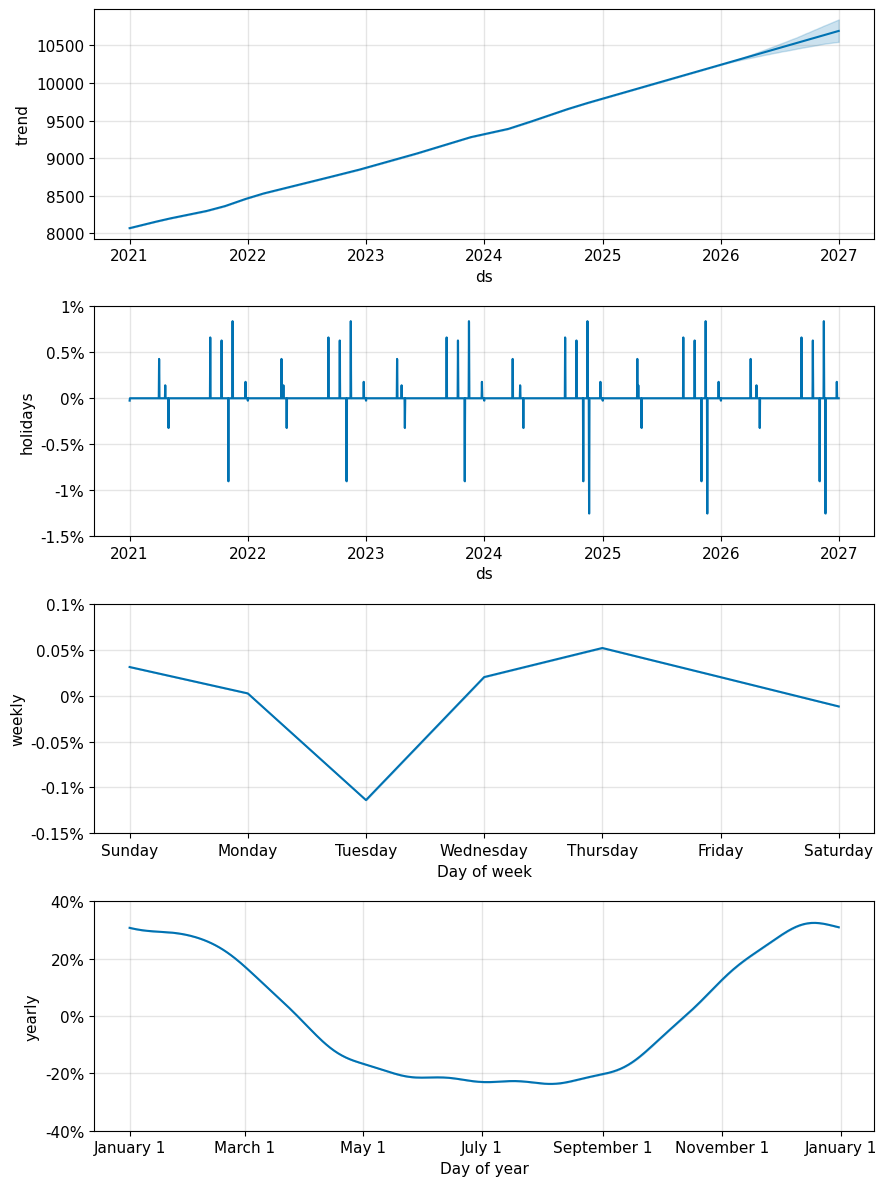

In [10]:
# Componentes da decomposição do Prophet
fig_comp = model_prophet.plot_components(forecast_prophet)
plt.tight_layout()
plt.show()

## 3. Random Forest

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

def build_features(idx: pd.DatetimeIndex) -> pd.DataFrame:
    """Engenharia de features temporais para o Random Forest."""
    df_feat = pd.DataFrame(index=idx)
    df_feat['day_of_year']  = idx.dayofyear
    df_feat['day_of_week']  = idx.dayofweek      # 0=seg, 6=dom
    df_feat['week_of_year'] = idx.isocalendar().week.astype(int)
    df_feat['month']        = idx.month
    df_feat['quarter']      = idx.quarter
    df_feat['year']         = idx.year
    df_feat['is_weekend']   = (idx.dayofweek >= 5).astype(int)
    # Ciclicidade: dia da semana, dia do ano, mês e semana do ano
    df_feat['sin_dow']   = np.sin(2 * np.pi * df_feat['day_of_week'] / 7)
    df_feat['cos_dow']   = np.cos(2 * np.pi * df_feat['day_of_week'] / 7)
    df_feat['sin_doy']   = np.sin(2 * np.pi * df_feat['day_of_year'] / 365.25)
    df_feat['cos_doy']   = np.cos(2 * np.pi * df_feat['day_of_year'] / 365.25)
    df_feat['sin_month'] = np.sin(2 * np.pi * df_feat['month'] / 12)
    df_feat['cos_month'] = np.cos(2 * np.pi * df_feat['month'] / 12)
    df_feat['sin_week']  = np.sin(2 * np.pi * df_feat['week_of_year'] / 52)
    df_feat['cos_week']  = np.cos(2 * np.pi * df_feat['week_of_year'] / 52)
    return df_feat

# Features de lags e médias móveis sobre o histórico
df_rf = serie.to_frame()

# Lags de curto prazo (dentro do mês)
for lag in [1, 2, 3, 7, 14, 21, 28, 30]:
    df_rf[f'lag_{lag}'] = df_rf['volume'].shift(lag)

# Lags anuais: referenciam dados reais do ano anterior — principal fonte de sazonalidade
# Para previsão de 2026 esses lags SEMPRE apontam para o histórico real (nunca para previsões)
for lag in [364, 365, 371, 730]:
    df_rf[f'lag_{lag}'] = df_rf['volume'].shift(lag)

for window in [7, 14, 30]:
    df_rf[f'roll_mean_{window}'] = df_rf['volume'].shift(1).rolling(window).mean()
    df_rf[f'roll_std_{window}']  = df_rf['volume'].shift(1).rolling(window).std()

# Médias móveis ancoradas no mesmo período do ano anterior (captura padrão sazonal local)
for window in [7, 30]:
    df_rf[f'roll_mean_{window}_ly'] = df_rf['volume'].shift(365).rolling(window, center=True).mean()

feat_temporais = build_features(df_rf.index)
df_rf = pd.concat([df_rf, feat_temporais], axis=1).dropna()

X = df_rf.drop(columns=['volume'])
y = df_rf['volume']

# Treino: anos < 2025 | Validação: 2025
X_train = X[X.index.year < 2025]
y_train = y[y.index.year < 2025]
X_val   = X[X.index.year == 2025]
y_val   = y[y.index.year == 2025]

rf_model = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,       # sem limite — árvores profundas capturam padrões complexos
    min_samples_leaf=3,
    max_features=0.5,     # ~50% das features por split reduz overfitting
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_val = rf_model.predict(X_val)
mae  = mean_absolute_error(y_val, y_pred_val)
rmse = mean_squared_error(y_val, y_pred_val) ** 0.5
print(f"Validação 2025 → MAE: {mae:,.1f} | RMSE: {rmse:,.1f}")

Validação 2025 → MAE: 106.4 | RMSE: 135.7


In [12]:
# Previsão iterativa para 2026
# Lags curtos (1–30 dias) podem referenciar previsões anteriores;
# lags anuais (364, 365, 371, 730) sempre referenciam o histórico real de 2024/2025.
future_index_rf = pd.date_range('2026-01-01', '2026-12-31', freq='D')

historico = serie.copy()

preds_rf = []
for data in future_index_rf:
    feat_row = build_features(pd.DatetimeIndex([data]))

    # Lags de curto prazo
    for lag in [1, 2, 3, 7, 14, 21, 28, 30]:
        ref_date = data - pd.Timedelta(days=lag)
        feat_row[f'lag_{lag}'] = historico.get(ref_date, np.nan)

    # Lags anuais — sempre dados históricos reais para 2026
    for lag in [364, 365, 371, 730]:
        ref_date = data - pd.Timedelta(days=lag)
        feat_row[f'lag_{lag}'] = historico.get(ref_date, np.nan)

    for window in [7, 14, 30]:
        past_vals = historico[historico.index < data].iloc[-window:]
        feat_row[f'roll_mean_{window}'] = past_vals.mean() if len(past_vals) == window else np.nan
        feat_row[f'roll_std_{window}']  = past_vals.std()  if len(past_vals) == window else np.nan

    # Médias móveis do mesmo período do ano anterior
    for window in [7, 30]:
        ref_center = data - pd.Timedelta(days=365)
        half = window // 2
        past_ly = historico[
            (historico.index >= ref_center - pd.Timedelta(days=half)) &
            (historico.index <= ref_center + pd.Timedelta(days=half))
        ]
        feat_row[f'roll_mean_{window}_ly'] = past_ly.mean() if len(past_ly) > 0 else np.nan

    pred = rf_model.predict(feat_row[X_train.columns])[0]
    preds_rf.append(pred)
    historico[data] = pred  # alimenta os próximos lags curtos com a previsão

df_rf_2026 = pd.DataFrame({'previsao_rf': preds_rf}, index=future_index_rf)
df_rf_2026.index.name = 'data'
df_rf_2026.head(10)

,previsao_rf
data,
2026-01-01,13109.130452
2026-01-02,13117.612561
2026-01-03,13119.015498
2026-01-04,13117.475372
2026-01-05,13115.702661
2026-01-06,13121.137512
2026-01-07,13116.571314
2026-01-08,13116.411759
2026-01-09,13117.573511


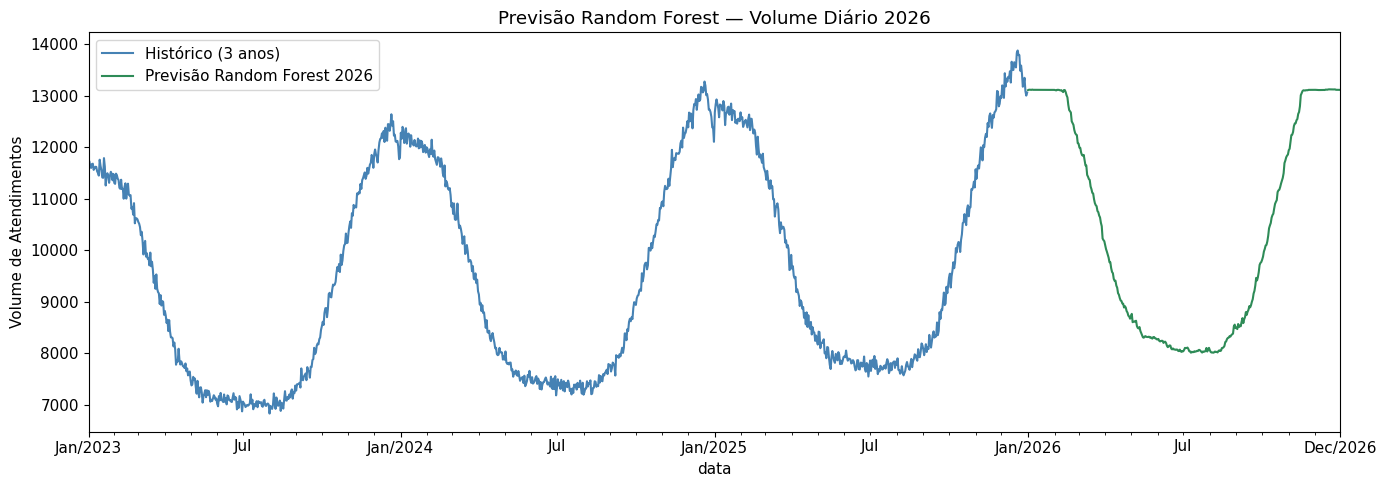

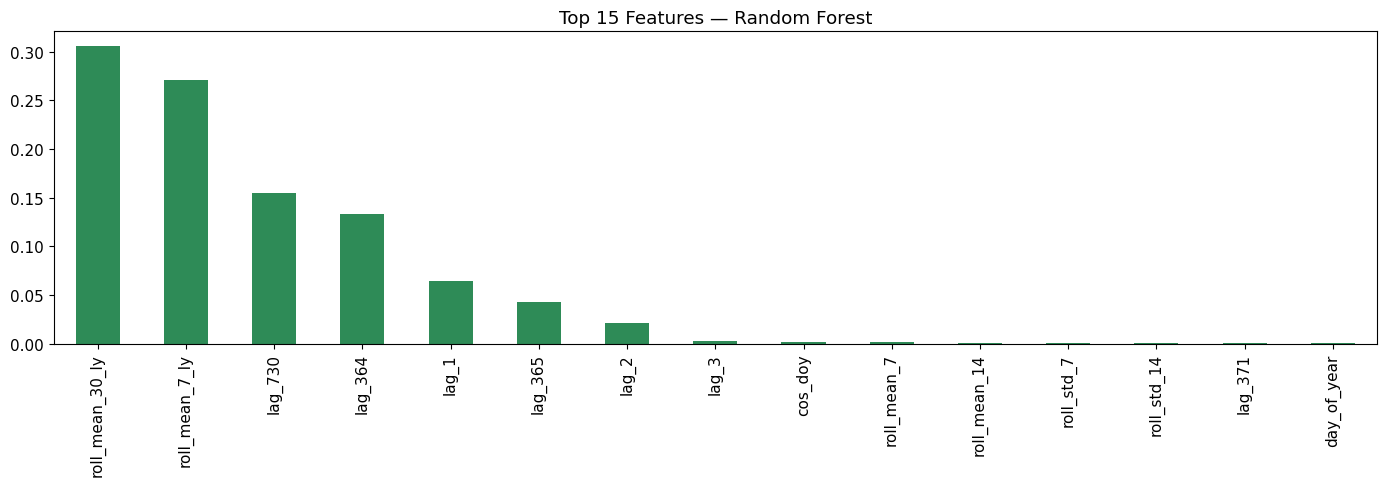


Total previsto 2026 (Random Forest): 3,794,239


In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
serie.iloc[-1095:].plot(ax=ax, label='Histórico (3 anos)', color='steelblue')
df_rf_2026['previsao_rf'].plot(ax=ax, label='Previsão Random Forest 2026', color='seagreen')
ax.set_title('Previsão Random Forest — Volume Diário 2026')
ax.set_ylabel('Volume de Atendimentos')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
plt.tight_layout()
plt.show()

# Importância das features
feat_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
feat_imp.head(15).plot(kind='bar', title='Top 15 Features — Random Forest', color='seagreen')
plt.tight_layout()
plt.show()

print(f"\nTotal previsto 2026 (Random Forest): {df_rf_2026['previsao_rf'].sum():,.0f}")

## 4. Comparação dos Três Modelos

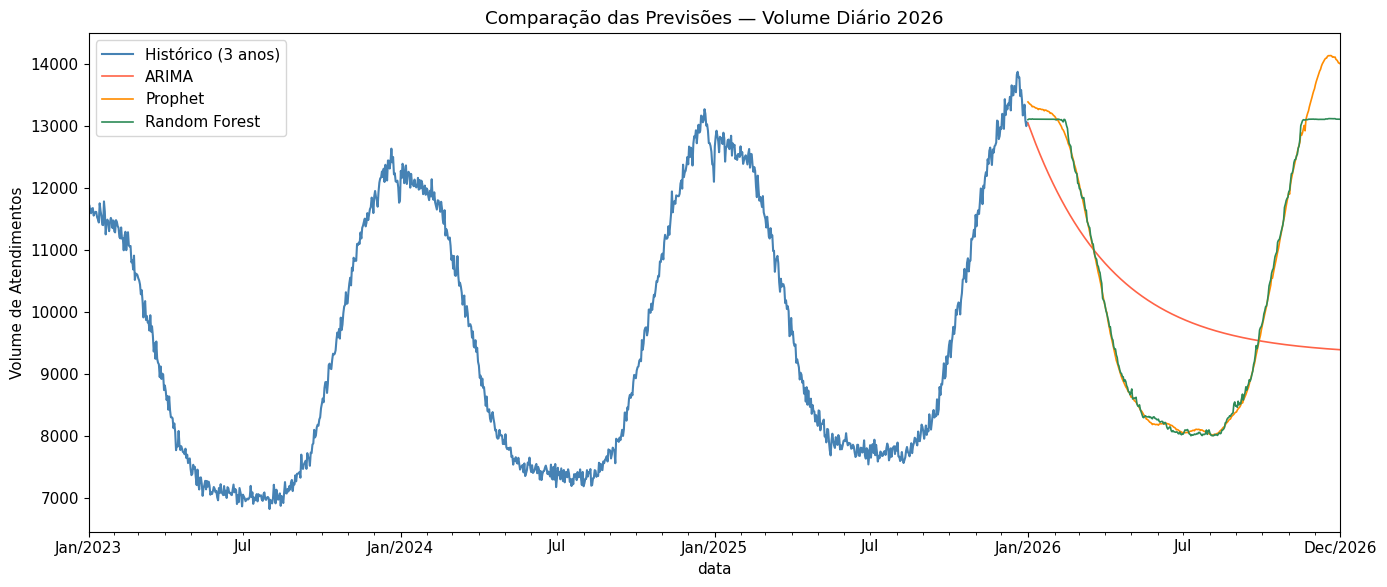

In [14]:
df_comparacao = pd.DataFrame({
    'ARIMA':         df_arima['previsao_arima'],
    'Prophet':       df_prophet_2026['previsao_prophet'],
    'RandomForest':  df_rf_2026['previsao_rf'],
})
df_comparacao.index.name = 'data'

fig, ax = plt.subplots(figsize=(14, 6))
serie.iloc[-1095:].plot(ax=ax, label='Histórico (3 anos)', color='steelblue', linewidth=1.5)
df_comparacao['ARIMA'].plot(ax=ax, label='ARIMA', color='tomato', linewidth=1.2)
df_comparacao['Prophet'].plot(ax=ax, label='Prophet', color='darkorange', linewidth=1.2)
df_comparacao['RandomForest'].plot(ax=ax, label='Random Forest', color='seagreen', linewidth=1.2)
ax.set_title('Comparação das Previsões — Volume Diário 2026')
ax.set_ylabel('Volume de Atendimentos')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
plt.tight_layout()
plt.show()

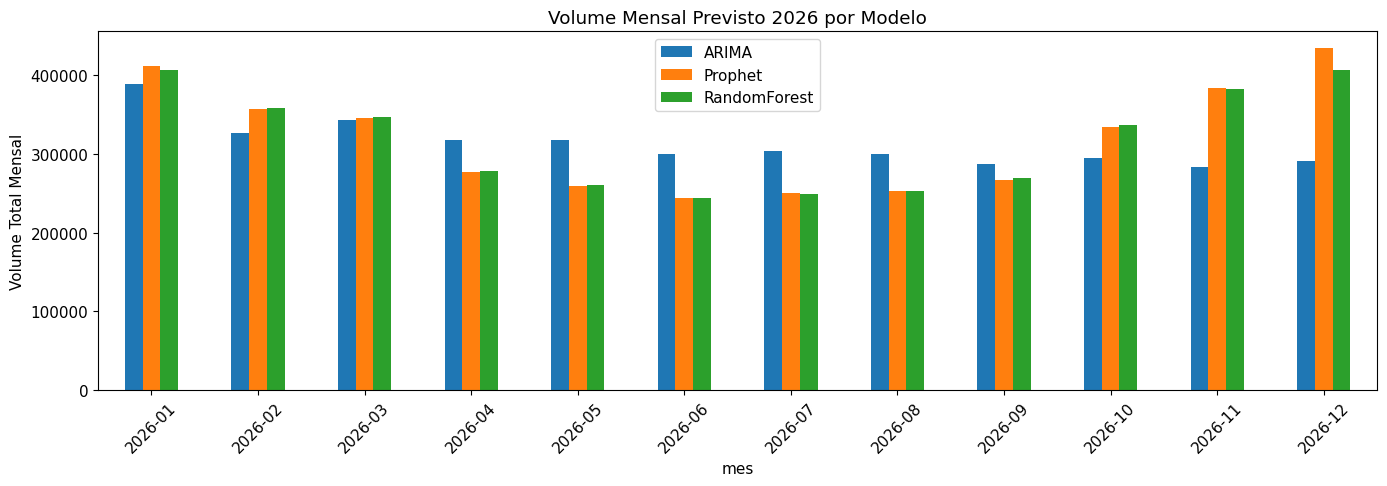


--- Total Anual Previsto 2026 ---
ARIMA           3,753,987
Prophet         3,819,954
RandomForest    3,794,239
dtype: str


In [15]:
# Resumo mensal
df_comparacao['mes'] = df_comparacao.index.to_period('M')
resumo_mensal = df_comparacao.groupby('mes')[['ARIMA', 'Prophet', 'RandomForest']].sum()
resumo_mensal.index = resumo_mensal.index.astype(str)

resumo_mensal.plot(kind='bar', figsize=(14, 5), title='Volume Mensal Previsto 2026 por Modelo')
plt.ylabel('Volume Total Mensal')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n--- Total Anual Previsto 2026 ---")
print(df_comparacao[['ARIMA', 'Prophet', 'RandomForest']].sum().apply(lambda x: f"{x:,.0f}"))

In [16]:
# Exporta as previsões para CSV
df_export = df_comparacao.drop(columns=['mes'])
df_export.to_csv('../Bases/previsao_volume_2026.csv')
print("Arquivo salvo em: Bases/previsao_volume_2026.csv")
df_export.head()

Arquivo salvo em: Bases/previsao_volume_2026.csv


,ARIMA,Prophet,RandomForest
data,,,
2026-01-01,13051.042769,13394.500534,13109.130452
2026-01-02,13013.936346,13379.464478,13117.612561
2026-01-03,12975.938205,13362.535557,13119.015498
2026-01-04,12938.329599,13354.208061,13117.475372
2026-01-05,12901.106534,13339.571538,13115.702661


## 5. Avaliação dos Modelos — Validação em 2025

Para mensurar a qualidade preditiva de cada modelo, separamos **2025 como conjunto de teste** (dados nunca vistos durante o treino). ARIMA e Prophet são retreinados usando apenas os dados até 31/12/2024; o Random Forest já possui essa validação calculada acima.

Métricas avaliadas:
- **MAE** — Erro Absoluto Médio (mesma unidade do volume; menor = melhor)
- **RMSE** — Raiz do Erro Quadrático Médio (penaliza erros grandes; menor = melhor)
- **MAPE** — Erro Percentual Absoluto Médio (interpretação em %; menor = melhor)
- **R²** — Coeficiente de Determinação (1 = perfeito, 0 = modelo sem poder explicativo)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Conjuntos de validação: treino até 2024, teste = 2025
serie_treino_val = serie[serie.index.year < 2025]
serie_val_real   = serie[serie.index.year == 2025]

print(f"Treino: {serie_treino_val.index.min().date()} → {serie_treino_val.index.max().date()}  ({len(serie_treino_val)} dias)")
print(f"Teste : {serie_val_real.index.min().date()} → {serie_val_real.index.max().date()}  ({len(serie_val_real)} dias)")

Treino: 2021-01-01 → 2024-12-31  (1461 dias)
Teste : 2025-01-01 → 2025-12-31  (365 dias)


In [18]:
# --- ARIMA: retreino em dados pré-2025 e previsão de 2025 ---
print("Retreinando ARIMA para validação em 2025 (pode levar alguns minutos)...")
arima_val = auto_arima(
    serie_treino_val,
    seasonal=True, m=7,
    stepwise=True,
    information_criterion='aic',
    error_action='ignore',
    suppress_warnings=True,
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    trace=False
)
y_pred_arima_val_arr, _ = arima_val.predict(
    n_periods=len(serie_val_real), return_conf_int=True
)
y_pred_arima_val = pd.Series(y_pred_arima_val_arr, index=serie_val_real.index, name='arima')
print(f"Modelo: {arima_val.order}  {arima_val.seasonal_order}")

Retreinando ARIMA para validação em 2025 (pode levar alguns minutos)...
Modelo: (0, 2, 2)  (0, 0, 0, 7)


In [19]:
# --- Prophet: retreino em dados pré-2025 e previsão de 2025 ---
print("Retreinando Prophet para validação em 2025...")
df_prophet_train_val = serie_treino_val.reset_index().rename(columns={'data': 'ds', 'volume': 'y'})

model_prophet_val = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    interval_width=0.95,
    changepoint_prior_scale=0.1
)
model_prophet_val.add_country_holidays(country_name='BR')
model_prophet_val.fit(df_prophet_train_val)

future_val       = model_prophet_val.make_future_dataframe(periods=365, freq='D')
forecast_val     = model_prophet_val.predict(future_val)
y_pred_prophet_val = (
    forecast_val
    .set_index('ds')['yhat']
    .loc['2025-01-01':'2025-12-31']
    .reindex(serie_val_real.index)
)
y_pred_prophet_val.name = 'prophet'
print("Prophet retreinado com sucesso.")

16:00:38 - cmdstanpy - INFO - Chain [1] start processing


Retreinando Prophet para validação em 2025...


16:00:38 - cmdstanpy - INFO - Chain [1] done processing


Prophet retreinado com sucesso.


In [20]:
# --- Tabela de métricas comparativa ---
def metricas_modelo(y_real, y_pred, nome):
    y_real  = np.array(y_real,  dtype=float)
    y_pred  = np.array(y_pred,  dtype=float)
    mask    = ~np.isnan(y_real) & ~np.isnan(y_pred) & (y_real != 0)
    mae  = mean_absolute_error(y_real[mask], y_pred[mask])
    rmse = mean_squared_error(y_real[mask], y_pred[mask]) ** 0.5
    mape = (np.abs((y_real[mask] - y_pred[mask]) / y_real[mask]) * 100).mean()
    r2   = r2_score(y_real[mask], y_pred[mask])
    return {'Modelo': nome, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape, 'R²': r2}

df_metricas = pd.DataFrame([
    metricas_modelo(serie_val_real, y_pred_arima_val,              'ARIMA'),
    metricas_modelo(serie_val_real, y_pred_prophet_val,            'Prophet'),
    metricas_modelo(y_val,          pd.Series(y_pred_val, index=y_val.index), 'Random Forest'),
]).set_index('Modelo')

# Exibição formatada
df_fmt = df_metricas.copy()
df_fmt['MAE']      = df_metricas['MAE'].map('{:,.1f}'.format)
df_fmt['RMSE']     = df_metricas['RMSE'].map('{:,.1f}'.format)
df_fmt['MAPE (%)'] = df_metricas['MAPE (%)'].map('{:.2f}%'.format)
df_fmt['R²']       = df_metricas['R²'].map('{:.4f}'.format)

print("=== Métricas de Qualidade — Validação em 2025 ===")
display(df_fmt)

melhor = df_metricas['R²'].idxmax()
print(f"\nMelhor modelo por R²: {melhor} ({df_metricas.loc[melhor, 'R²']:.4f})")

=== Métricas de Qualidade — Validação em 2025 ===


,MAE,RMSE,MAPE (%),R²
Modelo,,,,
ARIMA,"8,867.2","11,189.0",87.89%,-27.2068
Prophet,97.8,123.1,0.99%,0.9966
Random Forest,106.4,135.7,1.07%,0.9955



Melhor modelo por R²: Prophet (0.9966)


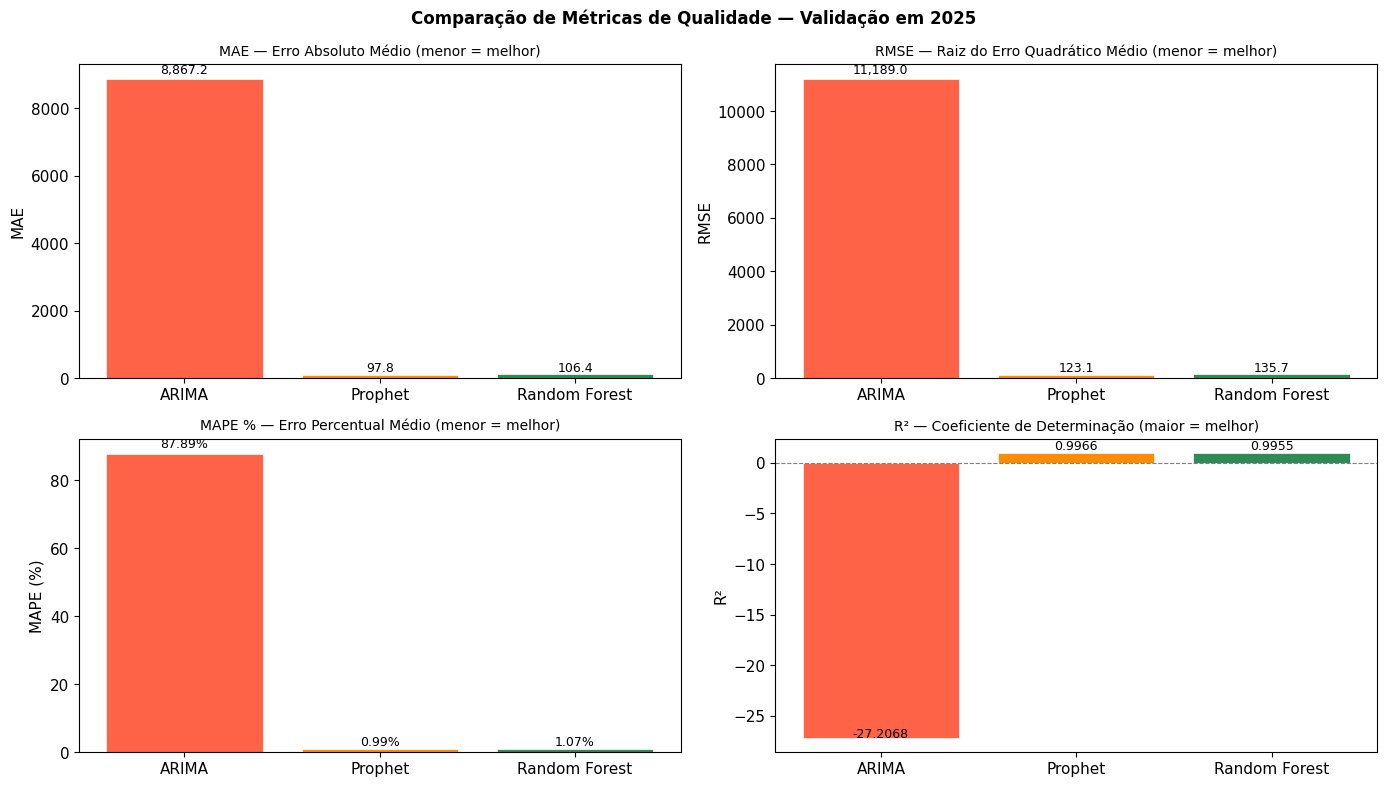

In [21]:
cores = ['tomato', 'darkorange', 'seagreen']
modelos = df_metricas.index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col, titulo in zip(
    axes.flat,
    ['MAE', 'RMSE', 'MAPE (%)', 'R²'],
    ['MAE — Erro Absoluto Médio (menor = melhor)',
     'RMSE — Raiz do Erro Quadrático Médio (menor = melhor)',
     'MAPE % — Erro Percentual Médio (menor = melhor)',
     'R² — Coeficiente de Determinação (maior = melhor)']
):
    bars = ax.bar(modelos, df_metricas[col], color=cores, edgecolor='white', linewidth=0.5)
    ax.set_title(titulo, fontsize=10)
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=0)
    for bar, val in zip(bars, df_metricas[col]):
        label = f'{val:.4f}' if col == 'R²' else f'{val:,.1f}' if col in ('MAE', 'RMSE') else f'{val:.2f}%'
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                label, ha='center', va='bottom', fontsize=9)
    if col == 'R²':
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.suptitle('Comparação de Métricas de Qualidade — Validação em 2025', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

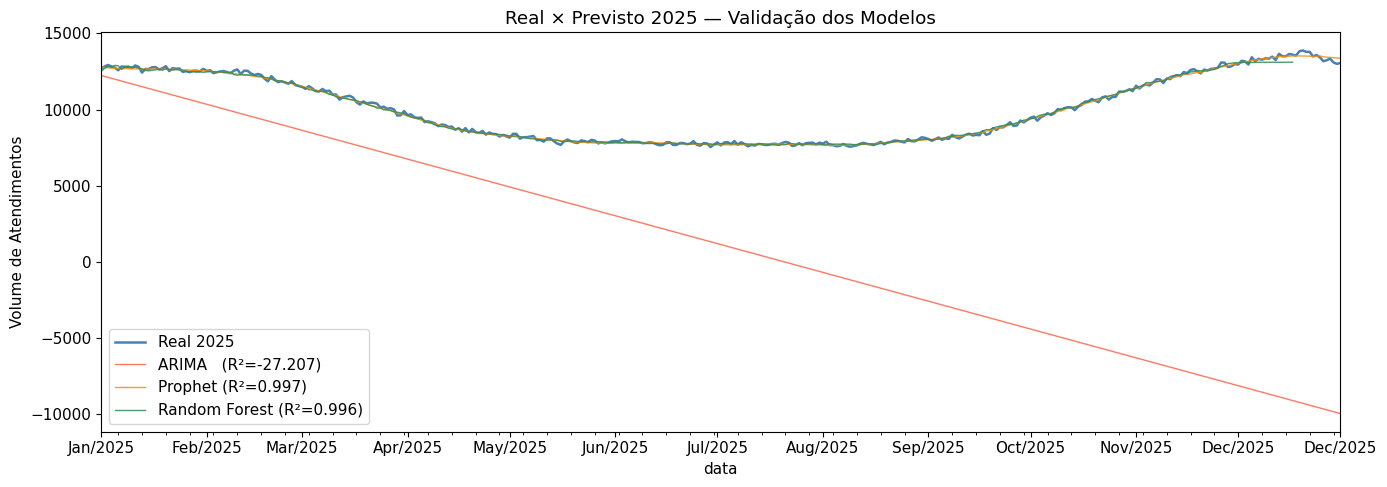

In [22]:
fig, ax = plt.subplots(figsize=(14, 5))
serie_val_real.plot(ax=ax, label='Real 2025', color='steelblue', linewidth=1.8)
y_pred_arima_val.plot(ax=ax,   label=f"ARIMA   (R²={df_metricas.loc['ARIMA','R²']:.3f})",         color='tomato',     linewidth=1.0, alpha=0.85)
y_pred_prophet_val.plot(ax=ax, label=f"Prophet (R²={df_metricas.loc['Prophet','R²']:.3f})",       color='darkorange',  linewidth=1.0, alpha=0.85)
pd.Series(y_pred_val, index=y_val.index).plot(
    ax=ax, label=f"Random Forest (R²={df_metricas.loc['Random Forest','R²']:.3f})",
    color='seagreen', linewidth=1.0, alpha=0.85
)
ax.set_title('Real × Previsto 2025 — Validação dos Modelos')
ax.set_ylabel('Volume de Atendimentos')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
plt.tight_layout()
plt.show()